# Custom Model — Lotka-Volterra

SeapoPym is not limited to marine ecosystem models. Any system of ODEs on a grid can be expressed as a **Blueprint**. This example builds the classic [Lotka-Volterra](https://en.wikipedia.org/wiki/Lotka%E2%80%93Volterra_equations) predator-prey model from scratch.

$$\frac{dN}{dt} = \alpha N - \beta N P \qquad \frac{dP}{dt} = \delta \beta N P - \gamma P$$

where $\alpha$ is the prey growth rate, $\beta$ the predation rate, $\delta$ the conversion efficiency, and $\gamma$ the predator mortality rate.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from seapopym.blueprint import Blueprint, Config, functional
from seapopym.compiler import compile_model
from seapopym.engine import simulate

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. Define the Physics

Each term of the ODE system is a pure function decorated with `@functional`. The decorator registers the function in SeapoPym's registry and declares its unit signature for compile-time validation.

In [2]:
@functional(
    name="lv:prey_growth",
    units={"N": "kg/m^2", "alpha": "1/s", "return": "kg/m^2/s"},
)
def prey_growth(N, alpha):
    """Prey exponential growth: +alpha * N."""
    return alpha * N


@functional(
    name="lv:predation",
    units={
        "N": "kg/m^2",
        "P": "kg/m^2",
        "beta": "m^2/kg/s",
        "delta": "dimensionless",
        "prey_loss": "kg/m^2/s",
        "predator_gain": "kg/m^2/s",
    },
    outputs=("prey_loss", "predator_gain"),
)
def predation(N, P, beta, delta):
    """Predation interaction: prey loses beta*N*P, predator gains delta*beta*N*P."""
    interaction = beta * N * P
    return -interaction, delta * interaction


@functional(
    name="lv:predator_death",
    units={"P": "kg/m^2", "gamma": "1/s", "return": "kg/m^2/s"},
)
def predator_death(P, gamma):
    """Predator natural mortality: -gamma * P."""
    return -gamma * P

## 2. Build the Blueprint

The Blueprint declares **state variables**, **parameters**, and the **process DAG** — which functions to call, with which inputs, producing which outputs. Tendencies define how derived fluxes feed back into state variables via Euler integration.

In [3]:
blueprint = Blueprint.from_dict({
    "id": "lotka-volterra",
    "version": "1.0",
    "declarations": {
        "state": {
            "prey": {"units": "kg/m^2", "dims": ["Y", "X"]},
            "predator": {"units": "kg/m^2", "dims": ["Y", "X"]},
        },
        "parameters": {
            "alpha": {"units": "1/s", "description": "Prey growth rate"},
            "beta": {"units": "m^2/kg/s", "description": "Predation rate"},
            "delta": {"units": "dimensionless", "description": "Conversion efficiency"},
            "gamma": {"units": "1/s", "description": "Predator mortality rate"},
        },
        "forcings": {},
    },
    "process": [
        {
            "func": "lv:prey_growth",
            "inputs": {"N": "state.prey", "alpha": "parameters.alpha"},
            "outputs": {"return": "derived.prey_growth"},
        },
        {
            "func": "lv:predation",
            "inputs": {
                "N": "state.prey",
                "P": "state.predator",
                "beta": "parameters.beta",
                "delta": "parameters.delta",
            },
            "outputs": {
                "prey_loss": "derived.prey_loss",
                "predator_gain": "derived.predator_gain",
            },
        },
        {
            "func": "lv:predator_death",
            "inputs": {"P": "state.predator", "gamma": "parameters.gamma"},
            "outputs": {"return": "derived.predator_death"},
        },
    ],
    "tendencies": {
        "prey": [
            {"source": "derived.prey_growth"},
            {"source": "derived.prey_loss"},
        ],
        "predator": [
            {"source": "derived.predator_gain"},
            {"source": "derived.predator_death"},
        ],
    },
})

### Process DAG

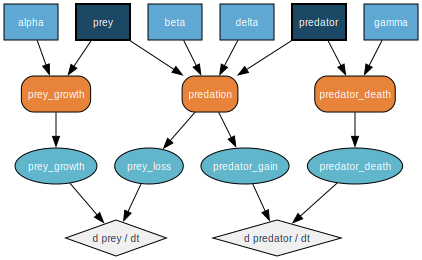

In [4]:
blueprint.to_graphviz()

## 3. Configure & Compile

The **Config** provides concrete parameter values, initial conditions, and execution settings. The compiler validates units, infers shapes, and produces a `CompiledModel` ready for JAX execution.

We use a single grid cell (1×1) — Lotka-Volterra is a purely temporal model, so no spatial structure is needed.

In [5]:
DAY = 86400.0  # seconds per day

config = Config.from_dict({
    "parameters": {
        "alpha": xr.DataArray(0.04 / DAY),     # prey growth: ~4% per day
        "beta": xr.DataArray(0.005 / DAY),      # predation rate
        "delta": xr.DataArray(0.5),              # conversion efficiency: 50%
        "gamma": xr.DataArray(0.1 / DAY),        # predator mortality: ~10% per day
    },
    "forcings": {},
    "initial_state": {
        "prey": xr.DataArray(np.array([[42.0]]), dims=["Y", "X"]),
        "predator": xr.DataArray(np.array([[7.0]]), dims=["Y", "X"]),
    },
    "execution": {
        "time_start": "2000-01-01",
        "time_end": "2002-12-31",
        "dt": "1d",
    },
})

model = compile_model(blueprint, config)
print(f"Compiled: {model.time_grid.n_timesteps} timesteps, dt = {model.dt:.0f}s")

Compiled: 1095 timesteps, dt = 86400s


## 4. Simulate

In [6]:
state, outputs = simulate(model)

prey = outputs["prey"].values[:, 0, 0]      # (T,) — single grid cell
predator = outputs["predator"].values[:, 0, 0]
time = np.arange(len(prey))

print(f"Prey     — min: {prey.min():.1f}, max: {prey.max():.1f}")
print(f"Predator — min: {predator.min():.1f}, max: {predator.max():.1f}")

Prey     — min: 15.4, max: 77.1
Predator — min: 2.1, max: 22.2


## 5. Results

### Population Dynamics

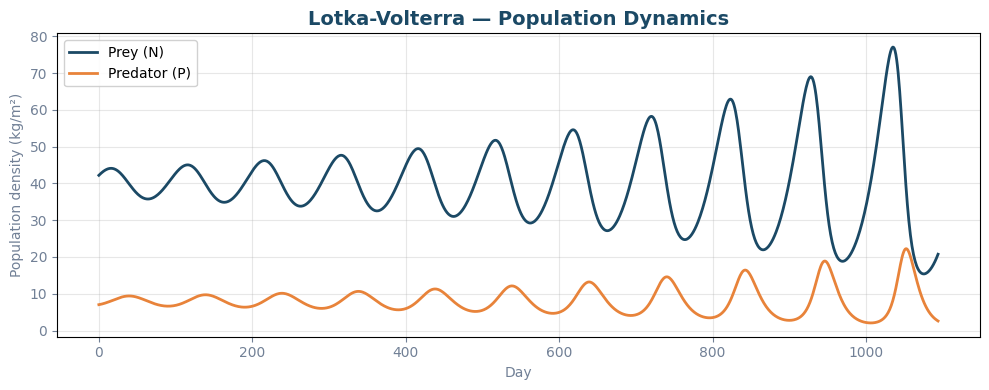

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time, prey, color=PALETTE[0], linewidth=2, label="Prey (N)")
ax.plot(time, predator, color=PALETTE[2], linewidth=2, label="Predator (P)")
ax.set_xlabel("Day", color="#718096")
ax.set_ylabel("Population density (kg/m²)", color="#718096")
ax.set_title("Lotka-Volterra — Population Dynamics", color="#1B4965", fontsize=14, fontweight="bold")
ax.legend(framealpha=0.9)
ax.tick_params(colors="#718096")
plt.tight_layout()
plt.show()

### Phase Portrait

The phase portrait reveals the characteristic closed orbits of the Lotka-Volterra system. The equilibrium point is at $N^* = \gamma / (\delta \beta)$, $P^* = \alpha / \beta$.

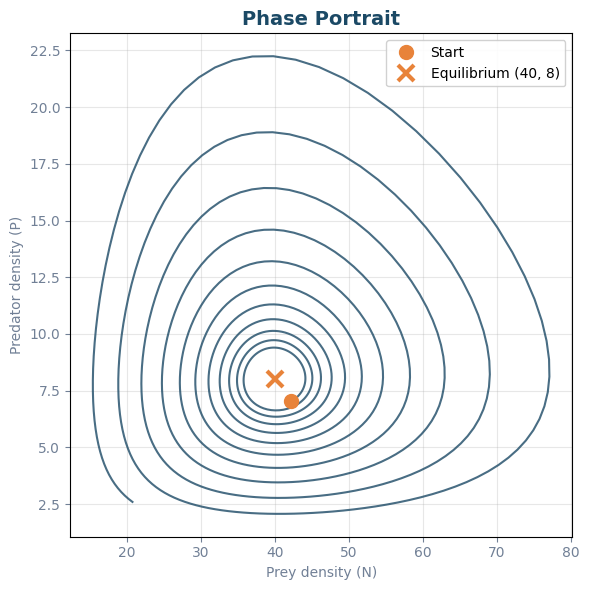

In [8]:
# Equilibrium point
N_star = 0.1 / (0.5 * 0.005)  # gamma / (delta * beta) = 40
P_star = 0.04 / 0.005          # alpha / beta = 8

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prey, predator, color=PALETTE[0], linewidth=1.5, alpha=0.8)
ax.plot(prey[0], predator[0], "o", color=PALETTE[2], markersize=10, zorder=5, label="Start")
ax.plot(N_star, P_star, "x", color=PALETTE[2], markersize=12, markeredgewidth=3, zorder=5, label=f"Equilibrium ({N_star:.0f}, {P_star:.0f})")
ax.set_xlabel("Prey density (N)", color="#718096")
ax.set_ylabel("Predator density (P)", color="#718096")
ax.set_title("Phase Portrait", color="#1B4965", fontsize=14, fontweight="bold")
ax.legend(framealpha=0.9)
ax.tick_params(colors="#718096")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

## Summary

This example demonstrated SeapoPym's **genericity**: any ODE system can be expressed as a Blueprint, compiled, and simulated — with no code changes to the framework.

| Step | Code |
|------|------|
| Define physics | 3 `@functional` functions (~20 lines) |
| Declare model | 1 `Blueprint.from_dict()` call |
| Configure | 1 `Config.from_dict()` call |
| Compile & run | `compile_model()` → `simulate()` |

The same pipeline applies to marine ecosystems (LMTL), biogeochemical models, or any dynamical system on a grid.

**Next**: [Gradient-Based Optimization](04_gradient.ipynb) — leverage JAX's automatic differentiation to compute gradients *through* the simulation.